In [ ]:
# https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf

In [ ]:
import torch
import torch.nn.functional as F

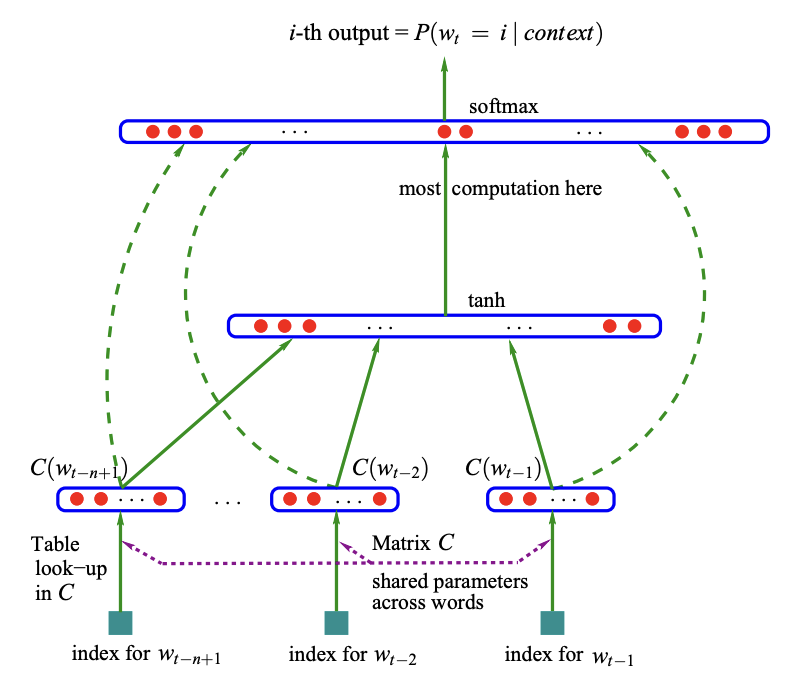

In [ ]:
# C is [17000, 30] 30 dimenstions to represent single input

In [ ]:
words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
ctoi = {c:i+1 for i,c in enumerate(chars)}
ctoi['.'] = 0

x = []
y = []

block_size = 3
for word in words:
  input = [0] * block_size
  word = word + '.'

  for c in word:
    y.append(ctoi[c])
    x.append(input)
    input = input[1:] + [ctoi[c]]


X = torch.tensor(x)
Y = torch.tensor(y)

X.shape, Y.shape


(torch.Size([228146, 3]), torch.Size([228146]))

In [ ]:
look_up_table = torch.randn(27,2)

In [ ]:
emb = look_up_table[X]
emb.shape

torch.Size([228146, 3, 2])

In [ ]:
W1 = torch.randn(6, 100) # 6 hardcoded - depends on
b1 = torch.randn(100)

In [ ]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h.shape

torch.Size([228146, 100])

In [ ]:
W2 = torch.randn(100,27)
b2 = torch.randn(27)

In [ ]:
logits = h @ W2 + b2
logits.shape

torch.Size([228146, 27])

In [ ]:
counts = logits.exp()

In [ ]:
prob = counts / counts.sum(1, keepdim=True)
prob.shape

torch.Size([228146, 27])

In [ ]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [ ]:
#=====================Training============================
# Dataset
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [ ]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

In [ ]:
sum(p.nelement() for p in parameters)

3481

In [ ]:
for p in parameters:
  p.requires_grad = True

In [ ]:
for _ in range(10000):

  #mini batch
  ix = torch.randint(0, X.shape[0], (32,))

  # Forward pass
  emb = C[X[ix]] # [32, 3, 2] <-- when 32 inputs
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # [32, 100]

  logits = h @ W2 + b2 # [32, 27]
  loss = F.cross_entropy(logits, Y[ix]) # <-- includes exp and prob and normalization

  # print(loss.item())

  # Backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  for p in parameters:
    p.data += -0.1 * p.grad

print(loss.item())

2.1365721225738525
